In [2]:
# 텐서플로 라이브러리 안에 있는 케라스 API에서 필요한 함수들을 불러옵니다.
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense   

# 데이터를 다루는 데 필요한 라이브러리를 불러옵니다.
import numpy as np
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense, Input

In [6]:
# 1. 데이터 로드

from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [7]:
# 2. 학습 / 테스트 분리

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

In [8]:
# 3. 정규화

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [10]:
# 4. 모델 생성

model = Sequential([
    Input(shape=(4,)),  # 컬럼 4개
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dense(3, activation="softmax"),  # 다중분류의 마지막 출력층은 기본적으로 softmax 사용
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 5. 컴파일

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # 3개 이상의 loss에서는 무조건 사용
    metrics=["accuracy"]
)

In [12]:
# 6. 학습

history = model.fit(
    x_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.6250 - loss: 0.9594 - val_accuracy: 0.5833 - val_loss: 0.9739
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6771 - loss: 0.9498 - val_accuracy: 0.5833 - val_loss: 0.9657
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6771 - loss: 0.9413 - val_accuracy: 0.5833 - val_loss: 0.9577
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6771 - loss: 0.9332 - val_accuracy: 0.5833 - val_loss: 0.9495
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6875 - loss: 0.9250 - val_accuracy: 0.6250 - val_loss: 0.9413
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7500 - loss: 0.9167 - val_accuracy: 0.6250 - val_loss: 0.9334
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7812 - loss: 0.9085 - val_accuracy: 0.6667 - val_loss: 0.9256
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8125 - loss: 0.9009 - val_accuracy: 0.6667 - val_loss

In [13]:
# 7. 평가

loss, acc = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8333 - loss: 0.3870


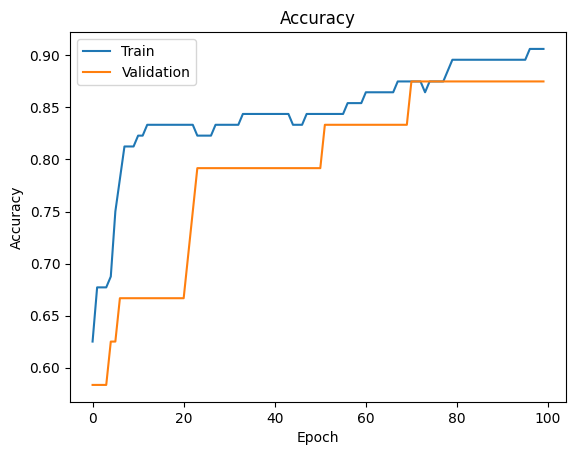

In [14]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

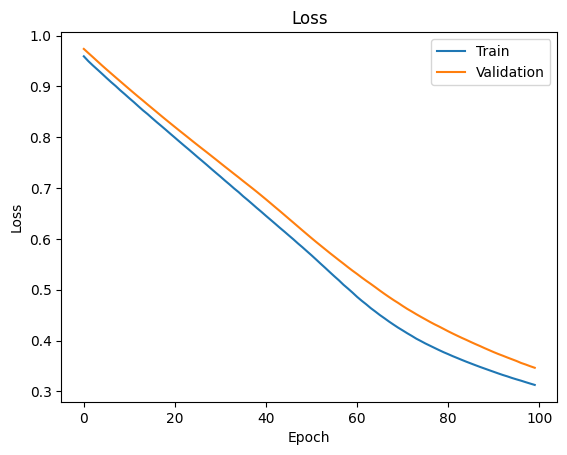

In [15]:
# 9. Loss 그래프

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [ ]:
# 10. 새로운 꽃 예측

new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
new_flower = scaler.transform(new_flower)  # 정규화된 데이터로 분석을 하고 있기 때문에 이것도 정규화를 시켜줘야 함 

pred = model.predict(new_flower)
pred

# array([[0.9659038 , 0.0053155 , 0.02878068]] 3종류 꽃에 대해 예측한 값 => 첫번째의 값이 가장 높기 떄문에 Setosa 품종일 확률이 높음 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


array([[0.9659038 , 0.0053155 , 0.02878068]], dtype=float32)